In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df['Churn'].value_counts())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

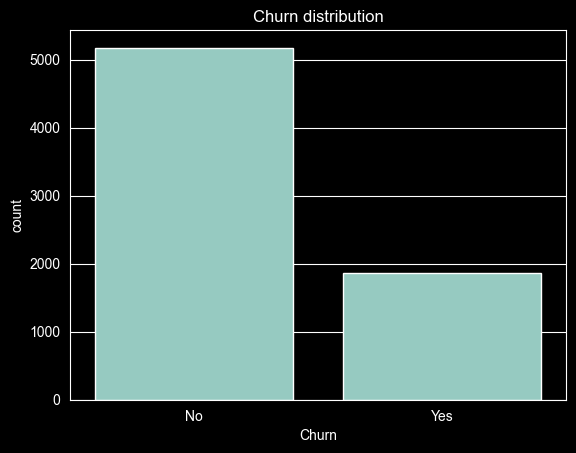

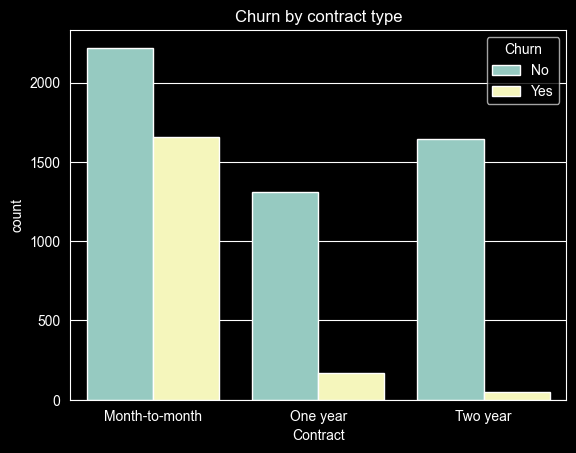

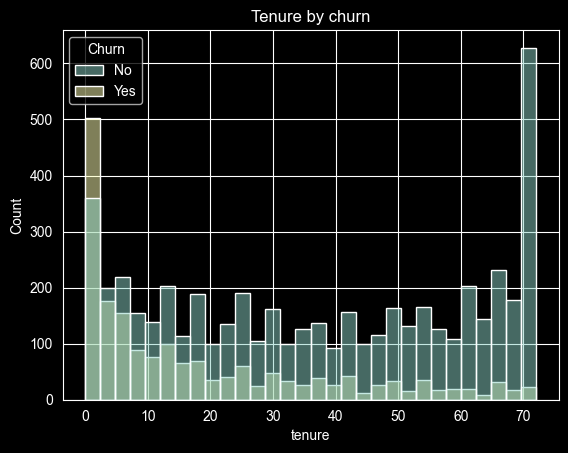

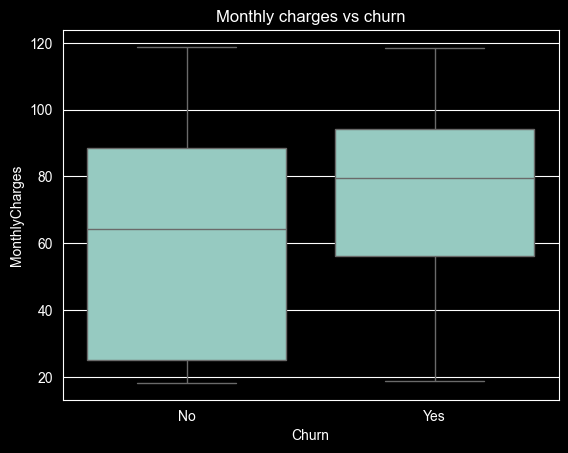

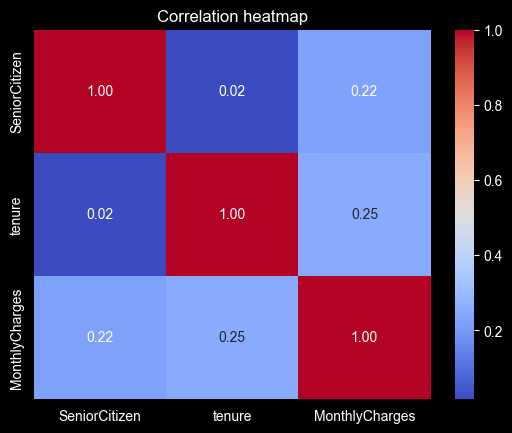

In [2]:
# Churn distribution
sns.countplot(data=df, x='Churn')
plt.title('Churn distribution')
plt.show()

# Churn by contract type
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by contract type')
plt.show()

# Tenure distribution
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title('Tenure by churn')
plt.show()

# Monthly charges boxplot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly charges vs churn')
plt.show()

# Correlation heatmap
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

In [3]:
# Fix TotalCharges (has spaces causing object type)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# One-hot encode multi-category columns
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Verify
print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())
print("Columns:", df.columns.tolist())

Shape: (7043, 31)
Nulls: 0
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


C:\Users\Pratik Karale\AppData\Local\Temp\ipykernel_15188\2120736975.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = df.drop('Churn', axis=1)
y = df['Churn']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale (important for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Train and evaluate all 3 models
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, class_weight='balanced'), X_train_sc, X_test_sc),
    'Decision Tree':       (DecisionTreeClassifier(random_state=42), X_train, X_test),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test)
}

for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print('='*40)
    print(classification_report(y_test, preds, target_names=['No Churn', 'Churn']))


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.82      0.83      0.82      1035
       Churn       0.51      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg     

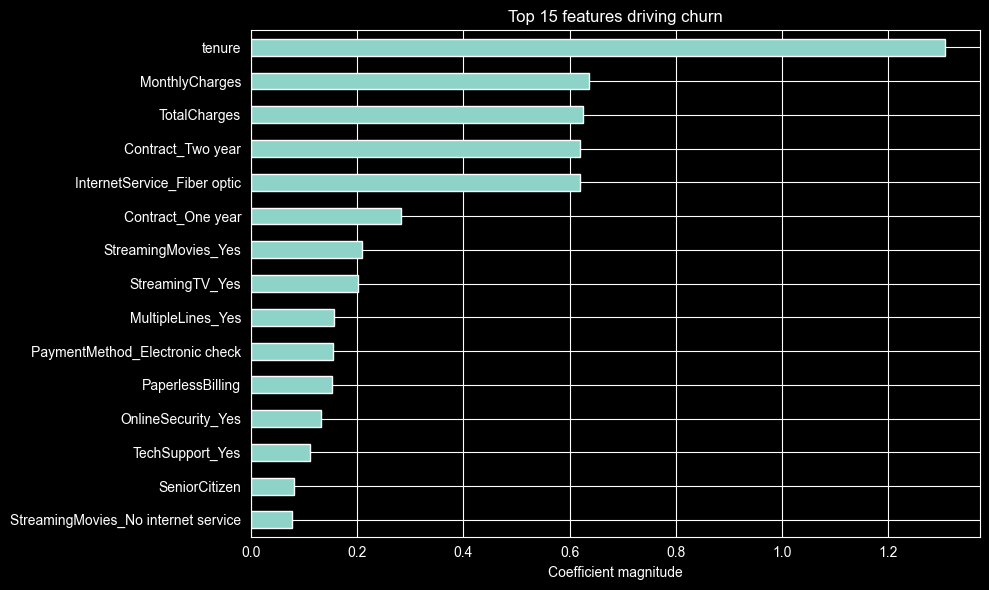

tenure                            1.307349
MonthlyCharges                    0.637049
TotalCharges                      0.624550
Contract_Two year                 0.620464
InternetService_Fiber optic       0.620215
Contract_One year                 0.283006
StreamingMovies_Yes               0.209123
StreamingTV_Yes                   0.201391
MultipleLines_Yes                 0.156619
PaymentMethod_Electronic check    0.154678
dtype: float64


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

final_model = LogisticRegression(max_iter=1000, class_weight='balanced')
final_model.fit(X_scaled, y)

# Get feature importance from coefficients
importance = pd.Series(
    final_model.coef_[0],
    index=X.columns
).abs().sort_values(ascending=False)

# Plot top 15
plt.figure(figsize=(10, 6))
importance[:15].plot(kind='barh')
plt.title('Top 15 features driving churn')
plt.xlabel('Coefficient magnitude')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance[:10])

In [9]:
import joblib
joblib.dump(final_model, '../Models/model.pkl')
joblib.dump(scaler_final, '../Models/scaler.pkl')

['../Models/scaler.pkl']